In [1]:
from feature_eng import TSFE # feature engineering py file
import logging
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)

#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
import  xgboost as xgb
import lightgbm as lgb
from sklearn.base import clone
# Model Evaluations
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import  TimeSeriesSplit,  GridSearchCV, train_test_split
from sklearn.metrics import PrecisionRecallDisplay

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h', '3D', '7D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h', '3D', '7D']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h', '3D', '7D']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                        ['CH4_w_roll_std_24h', 'CH4_w_roll_mean_24h'], ['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h'],['CH4_area_roll_std_24h', 'CH4_area_roll_mean_24h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

In [3]:
target ='label1'
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['type', 'pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'is_air', 'is_std'],
      dtype='object')


,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std
datetime,,,,,,,,,,,,,,
1994-02-16 14:29:00,air,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 14:49:00,air,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 15:09:00,air,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0
1994-02-16 15:29:00,air,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0
1994-02-16 18:00:00,air,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0


In [4]:
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.fit_transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()

['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [6]:
feature_ml = ['CH4_rt_to_last_air_ratio',
 'CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'CH4_end_time',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_diff_1',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_w_residual_24h',
 'CH4_ht_pflow_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_start_time',
 'CH4_ht_residual_1h',
 'CH4_w',
 'CH4_ht_diff_1',
 'CH4_w_residual_1h']

In [7]:
X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

In [8]:
def bagging_rf(n_bags, model, X_train_final, y_train):
    pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
    unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

    # obtain the number of positive and unlabeled data
    print(f"Number of Bag: {n_bags}")
    number_pos = len(pos_idx)
    print("Positive:", len(pos_idx))
    print("Unlabeled:", len(unl_idx))

    rng = np.random.default_rng(42)

    feature_importances = []
    models = []

    for bag in range(n_bags):
        sampled_pos = pos_idx

        #select same number data of positive data from unlabeld data
        sampled_unl_idx = rng.choice(
            unl_idx,
            size=number_pos,
            replace=False
        )

        sampled_idx = np.concatenate([
            pos_idx,
            sampled_unl_idx
        ])


        rng.shuffle(sampled_idx)

        X_pu = X_train_final.iloc[sampled_idx]
        y_pu = y_train.iloc[sampled_idx]

        print(
            f"\n PU training data, Bag {bag +1}/{n_bags} "
            f"Positive = {(y_pu ==1).sum()}, "
            f"Unlabeled = {(y_pu == 0).sum()}"
        )
        model.fit(X_pu, y_pu)
    return model
    


In [9]:
n_bags=30
base_rf =  xgb.XGBClassifier(
    learning_rate=0.1, max_depth=5, n_estimators= 200,
random_state=42
)
pu_clf= bagging_rf(n_bags, base_rf , X_train_final, y_train)
model = pu_clf

Number of Bag: 30
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 11/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 12/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 13/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 14/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 15/30 Pos

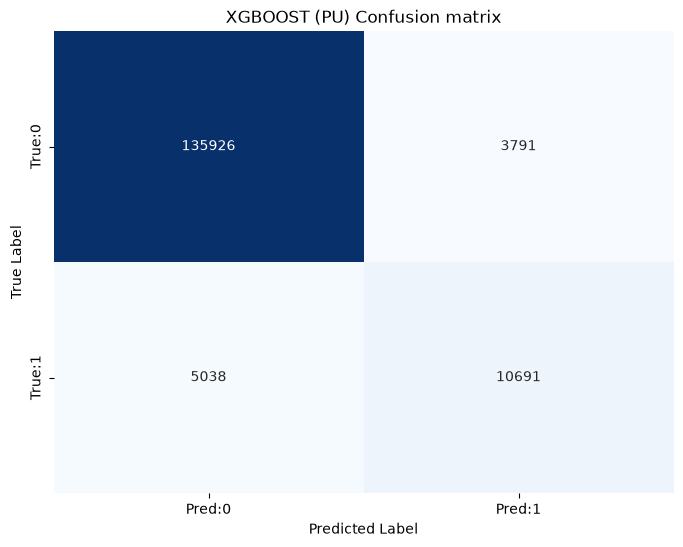

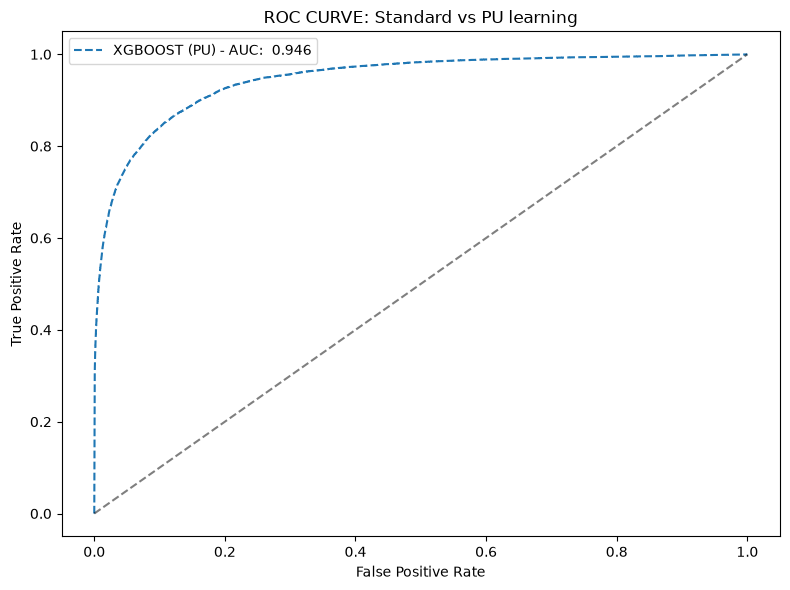

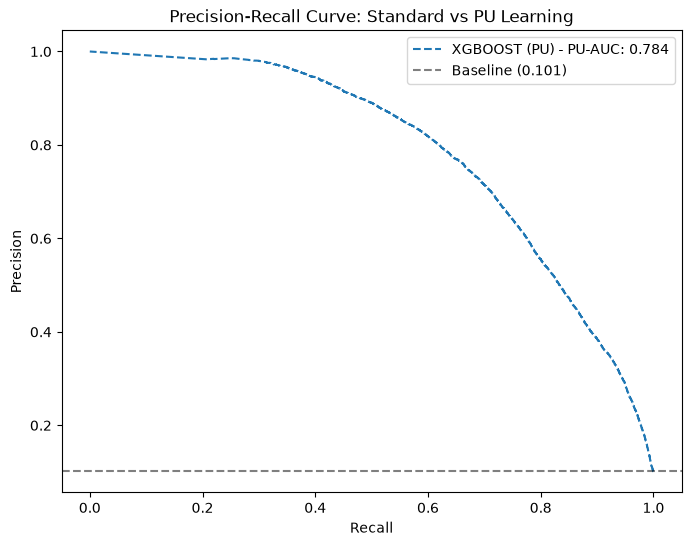

In [20]:
threshold = 0.8
name='XGBOOST'
y_prob_pu =  pu_clf.predict_proba(X_test_final)[:, 1]
y_pred_pu = (y_prob_pu >= threshold).astype(int)

auc_pu = roc_auc_score(y_test, y_prob_pu)
pr_auc_pu = average_precision_score(y_test, y_prob_pu)

#========================

fig_cm, axes_cm = plt.subplots(figsize=(8,6))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6))


#========================
fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

cm = confusion_matrix(y_test, y_pred_pu)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm, cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
axes_cm.set_title(f"{name} (PU) Confusion matrix")
axes_cm.set_xlabel("Predicted Label")
axes_cm.set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()


fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")


baseline_pr = np.sum(y_test == 1) / len(y_test)

ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()


plt.show()
